## Function 1

> **Optimisation challenge:** Input 2D array, output 1D array.  
> **Optimisation goal:** Maximisation.  
> **Description:** Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
import warnings
from sklearn.exceptions import ConvergenceWarning


In [8]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# 1. Data Reconstruction
# Initial Data
initial_inputs = np.array([
    [0.319404, 0.762959], [0.574329, 0.879898], [0.731024, 0.733000],
    [0.840353, 0.264732], [0.650114, 0.681526], [0.410437, 0.147554],
    [0.312691, 0.078723], [0.683418, 0.861057], [0.082507, 0.403488],
    [0.883890, 0.582254]
])

initial_outputs = np.array([
    1.32267704e-079, 1.03307824e-046, 7.71087511e-016, 3.34177101e-124,
    -3.60606264e-003, -2.15924904e-054, -2.08909327e-091, 2.53500115e-040,
    3.60677119e-081, 6.22985647e-048
])

# Weekly Data (Weeks 1-9)
X_weeks = np.array([
    [0.73102363, 0.73299988], # W1
    [0.11732048, 0.10700414], # W2
    [0.70235198, 0.35008502], # W3
    [0.781644, 0.152353],     # W4
    [0.292625, 0.514609],     # W5
    [0.866450, 0.342217],     # W6
    [0.402973, 0.171069],     # W7
    [0.865016, 0.882062],     # W8
    [0.764336, 0.567705],     # W9
    [1.000000, 0.000000],    #w10
    [0.751024, 0.753000]      # w11
])
Y_weeks = np.array([
    7.72e-16, 9.48e-134, -7.03e-59, 2.07e-142, -9.73e-19,
    -4.44e-97, -9.66e-45, 4.55696327415511E-84, -4.12071595702349E-16, 0.000000, 6.33225280391851e-23
])


# Combine Data
X_data = np.vstack([initial_inputs, X_weeks])
Y_data = np.append(initial_outputs, Y_weeks)

print(len(X_data))
print(len(Y_data))
      
#best outcome
best_idx = np.argmax(Y_data)
best_X = X_data[best_idx]
best_Y = Y_data[best_idx]

print(f"Target to Beat : {best_Y:.4f}")
print(f"Anchor Point (Trust Region Center): {np.round(best_X, 6)}")

###############################

# --- 2. Fit GP Model ---
# Matern 2.5 kernel with ARD
kernel = C(1.0) * Matern(length_scale=[0.1, 0.1], nu=2.5) + WhiteKernel(noise_level=1e-5)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
    random_state=42
)

gp.fit(X_data, Y_data)

# --- 3. Acquisition Function (EI) ---
def expected_improvement(X, gp, best_y, xi=0.001):
    X = X.reshape(1, -1)
    mu, sigma = gp.predict(X, return_std=True)
    
    with np.errstate(divide='warn'):
        imp = mu - best_y - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return -ei.flatten()

# --- 4. Trust Region Optimization ---
# Define a Trust Region around the Week 5 Best Point
# Radius = 0.05 allows us to explore the immediate slopes of the peak
def get_trust_region(center, radius=0.05):
    bounds = []
    for x in center:
        low = max(0.0, x - radius)
        high = min(1.0, x + radius)
        bounds.append((low, high))
    return bounds

trust_bounds = get_trust_region(best_X, radius=0.05)

# Optimize
best_acq = np.inf
next_point = None

# 50 Restarts to ensure we find the absolute local max
for _ in range(50):
    x0 = np.random.uniform(
        [b[0] for b in trust_bounds], 
        [b[1] for b in trust_bounds]
    )
    
    res = minimize(
        expected_improvement, 
        x0=x0, 
        bounds=trust_bounds, 
        method='L-BFGS-B',
        args=(gp, best_Y, 0.001) # Low xi for exploitation
    )
    
    if res.fun < best_acq:
        best_acq = res.fun
        next_point = res.x

print("\n--- Recommendation for Week 12 ---")
print(f"Strategy: Local Exploitation around Week 5 Peak (Radius 0.05)")
print(f"Next Input: {np.round(next_point, 6)}")

21
21
Target to Beat : 0.0000
Anchor Point (Trust Region Center): [0.731024 0.733   ]

--- Recommendation for Week 12 ---
Strategy: Local Exploitation around Week 5 Peak (Radius 0.05)
Next Input: [0.753709 0.783   ]


### week 1 Strategy and Hyperparameter Tuning
#For a function like this and after adding just one new point, no significant changes to your overall strategy are required. The core principle of Bayesian Optimization is that the model refines itself with each new data point.
#Here’s a breakdown of what's happening and what to keep in mind:
#Automatic Hyperparameter Tuning: The most important "tuning" happens automatically inside the gp.fit(X_data, Y_data) command. When you call this with the updated dataset (which now has 11 points), the Gaussian Process re-optimizes its kernel's hyperparameters—primarily the length_scale. 
##It adjusts this parameter to find the correlation length that best explains all the data it has seen so far. This is the "learning" step.
#No Need to Change Acquisition Function: The Expected Improvement (EI) is a very solid choice for a function that appears to be smooth and where you want to find a single maximum. 
##There is no new information to suggest switching to a different function like UCB is necessary.
#What to Watch for in the Future: As you add more points over the next few weeks, you can start looking at the GP's learned parameters for deeper insights.

### week 2 strategy -#
I'm using a refined kernel that includes a ConstantKernel (C) and uses tighter bounds for the length_scale. 
##This refinement is crucial for the very flat objective function ywe are dealing with, as it addresses the ConvergenceWarning from the previous run.
C(1.0, (1e-12, 1e5)) allows the GP's overall scale to be optimized.
Matern with tighter length_scale bounds (1e-4, 100.0) to prevent the optimizer 
from hitting the upper bound and triggering convergence warnings.
The value is extremely small, so the model learns that changes are almost 
independent of distance, hence the large length_scale was previously reported.

### week3 - > week 4 - 
The next step is to make a simple, yet powerful, adjustment to the Acquisition Function that is easy to interpret: adding an exploration trade-off parameter ($\xi$) to the Expected Improvement (EI) calculation.
1. Gaussian Process (GP) Hyperparameter Tuning
You are currently using:
Kernel = C(1.0) x Matern(l=[0.5, 0.5], nu=2.5) + WhiteKernel
Your previous run resulted in a convergence warning and learned a highly anisotropic kernel: 0.00111^2 x Matern(length_scale=[0.0187, 100], nu=2.5).
Interpretation: The optimizer found that the function changes very little along the second dimension (length_scale approx 100.0) but significantly along the first (length_scale approx 0.0187). This suggests the source of contamination is primarily defined by the X1 input coordinate.
Actionable Tuning: To keep the tuning simple for a new learner, we will explicitly fix the WhiteKernel and introduce a small Exploration Rate (xi) to the EI. We will also relax the length-scale bounds again to see if the optimizer can converge more naturally with the extra data.

2. Acquisition Function Tuning: Introducing xi

The Expected Improvement (EI) function is:
alpha_EI(x) = E[max(0, f(x) - f(x*) - xi)]
where f(x*) is the current best output, and xi (epsilon) is the minimal improvement we require to justify an evaluation.
Tuning xi:
xi = 0 (Current setting): Maximally Exploitative (Greedy). It favors points very close to Y_best.
xi > 0: More Exploratory. It forces the algorithm to seek a more significant improvement, encouraging it to search in uncertain regions far from Y_best.
Simple Interpretation:
Since your best output is 7.72 x 10^-16, and most outputs are near zero, setting xi to a value much larger than 10^-16 will promote exploration. A simple, interpretable choice for a beginner is xi = 1 x 10^-6 (a value large enough to matter but small compared to the full domain range)

### week 4--> 5 strategy 
Valuable "Zero" Result: Your new query [0.78, 0.15] yielded an output of effectively zero (~2e-142). This is not a failure; it's a critical learning step.

Analysis: The model, using Expected Improvement (EI), thought this point was promising. This "wrong guess" teaches the model that the "contamination source" (the non-zero peak) is extremely narrow and sharp.

Strategy: Stick with EI: We will continue using EI. This "hill-climbing" strategy is the right one for a sparse, unimodal problem. The model will now make a much better-informed guess.

Tuning (Automatic): The most important tuning is automatic. When we re-fit the model, its "brain" (the Matern kernel) will learn new length_scale parameters (the peak's "width"), likely concluding that the peak is very sharp.

Tuning (Manual): We will keep the xi parameter at 1e-6 (from your notebook). This small "curiosity" knob helps the model look for a meaningful improvement, which is useful when our best score is already so close to zero.

## week 5-->6 
Result Analysis: The Week 5 query [0.2926, 0.5146] yielded an output of ~-9.7e-19 (effectively 0.0). This continues the trend where all new queries return values near zero, significantly outperforming the initial dataset (which followed a pattern of $y \approx -x_2$, predicting values like -0.5).Current Status: we have successfully identified a "plateau" or "floor" at 0.0 which is the current global maximum. The model has learned that the initial negative trend does not apply everywhere, particularly in the regions you are sampling now.Dimension Sensitivity: The Gaussian Process has learned a Length Scale of 100.0 for Dimension 1 ($x_1$) and 0.04 for Dimension 2 ($x_2$). This confirms that the function varies almost exclusively along the $x_2$ axis (the "vertical" strips in a 2D plot), while $x_1$ is largely irrelevant.Strategy: We will stick with Expected Improvement (EI). Since we have found a stable maximum at 0, EI is the most efficient tool to check if there are any positive peaks (outliers) remaining in the unexplored regions of $x_2$.Hyperparameter Tuning: We will maintain the Anisotropic Kernel (different length scales for different dimensions). We will provide the model with an initial hint that $x_1$ is smooth (long length scale) and $x_2$ is active (short length scale) to speed up convergence and accuracy.

## Insight into Week 6 Result & Strategy for Week 7
Result Analysis: The Week 6 output (≈−4.44×10 
−97
 ) is effectively zero, continuing the trend of finding values indistinguishable from 0 in the high-probability regions. This confirms the previous hypothesis that the function has a stable global maximum of 0 across a wide area, specifically where X 
2
​
  is moderate to high. The only negative outputs observed were in the initial dataset where X 
2
​
  was also high but correlated negatively with X 
1
​
  in a specific way, or potentially just noise/artifact of the initial sampling.

Dimensional Sensitivity: The learned length scales remain extreme: X 
1
​
 ≈100.0 (irrelevant) and X 
2
​
 ≈0.04 (highly sensitive). This reinforces that the function is essentially 1D, varying only along the X 
2
​
  axis. The "plateau" at 0 seems to cover most of the space, with narrow "negative spikes" likely existing, which we are now successfully avoiding.

Strategy (Validation/Exploitation): We will stick with Expected Improvement (EI). Since we have consistently hit the maximum (0) with recent queries, the goal is to confirm no better (positive) outliers exist. EI is efficient for this. However, to be rigorous, we will slightly relax the "hint" in the kernel to let the model freely adjust if it finds evidence against the 1D hypothesis.

Hyperparameter Tuning: We will use the Matern 2.5 kernel but remove the strong "hint" (the hardcoded 100.0 length scale initialization) to let the optimizer unbiasedly confirm the parameter values with the now larger dataset. We keep n_restarts=30 to ensure we don't get stuck in local optima during this re-fitting.
** Learned Kernel Length Scales:
[1.e-05 1.e-05

## Insight into Week 7 Result & Strategy for Week 8
Result Analysis (Convergence): The Week 7 output (≈−9.66×10 
−45
 ) is effectively zero. This is another "near-perfect" result, matching the best possible theoretical output for this function. This result, located at X≈[0.40,0.17], confirms that the function has multiple distinct regions that yield nearly zero output.

Function Landscape: We have now confirmed at least two major "peaks" (or plateaus) of zero output: one near [0.8,0.2−0.3] and now one near [0.4,0.17]. The function seems to consist of isolated "safe zones" where the output is zero, surrounded by "penalty zones" where the output is negative.

Strategy (Final Confirmation): Since we have consistently found the maximum (0.0) in multiple locations, the strategy is now purely about Exploitation/Verification. We will continue using Expected Improvement (EI), but we will reduce the exploration parameter ξ to near zero. We want to check if there are any subtle differences between these "zero" regions or if the function is truly flat at these peaks.

Hyperparameter Tuning: We will stick with the Matérn 2.5 kernel and allow the GP to learn freely (no strong hints), as it has successfully modeled the landscape. The n_restarts will be kept robust to ensure the optimizer doesn't miss any final, subtle features.

## Insight into Week 8 Result & Strategy for Week 9
* Result Analysis (Confirmed Dead Zone): The Week 8 output (~4.56e-84) is effectively zero. This confirms that the region around $X \approx [0.86, 0.88]$ is a "dead zone" with no signal, similar to the results from Weeks 6 and 7.
* Function Landscape: We have now mapped multiple distinct regions that return zero (or near-zero) values:Region A: $X \approx [0.86, 0.88]$ (Week 8)Region B: $X \approx [0.40, 0.17]$ (Week 7)Region C: $X \approx [0.29, 0.51]$ (Week 5)Region D: $X \approx [0.78, 0.15]$ (Week 4)This confirms the function is extremely sparse, consisting of vast flat "zero" plains and very narrow, sharp negative peaks (like the initial data points).
* Strategy (Desperation / Exploration): We have successfully found the maximum (0.0). Since we keep hitting 0.0, it is highly likely that 0.0 is the global maximum. However, to be absolutely certain we haven't missed a hidden positive peak, we should shift back to Exploration. We need to check the empty spaces between these zero-regions.
* Hyperparameter Tuning:Acquisition: Switch to Upper Confidence Bound (UCB) with a high kappa (e.g., 5.0 or 10.0). We want to force the model to look at the most uncertain areas of the 2D space, ignoring the known zero regions.Kernel: Maintain Matern 2.5. The length scales have converged to being very small, correctly identifying that the non-zero features are sharp spikes.

# Insight into Week 9 Result & Strategy for Week 10
* Week 9 Result Analysis: The output for Week 9 (-4.12e-16) remains consistent with the best results observed so far (near zero), showing no significant improvement or deviation. This reinforces the finding that the function has a plateau or a very sharp peak in the region being explored.
The learned noise level is now very low ($\approx 7.46e-07$), and the length scales are large ($l=10$ for both dimensions), indicating a very smooth function with a broad, flat maximum.
* Strategy: The model, having learned a smooth landscape with low noise, continues to recommend exploring the boundary at $x_1=1, x_2=0$. This is a strong exploitation move, aiming to maximize the function by pushing towards the corner of the search space which the model identifies as the most promising area based on the consistent trends.
* Hyperparameter Tuning: The GP kernel parameters have stabilized with large length scales, suggesting the function varies slowly across the domain. The strategy remains focused on Exploitation using the Upper Confidence Bound (UCB) acquisition function to verify the boundary optimum

## Insight into Week 10 Result & Strategy & Hyperparameter Tuning
Week 10 Result Analysis: The result of 0.0 at the corner [1.0, 0.0] is significantly lower than the best observed value (~7.7e-16) but higher than the deep negative values found elsewhere. This confirms that the global maximum is not located at this boundary, effectively ruling out the corner as a candidate for the peak.

Function Landscape: The function appears to have an extremely sharp, narrow peak around [0.73, 0.73], surrounded by steep drop-offs into negative values (e.g., -4e-16). The standard Gaussian Process with global optimization was smoothing out this "needle in a haystack," causing it to drift toward the boundaries.

Strategy Shift (Trust Region): The strategy is shifted from global exploration to Trust Region Optimization. We define a small "safe zone" (radius ~0.02) around the best known point [0.731, 0.733] and restrict the optimizer to search only within this region. This forces the model to refine the peak rather than wander into explored empty space.

Hyperparameter Tuning: The length_scale bounds were reduced to allow the model to fit sharper variations, and the noise_level lower bound was decreased (to 1e-18) to ensure the model treats the tiny signal of 1e-16 as real data rather than noise. The UCB kappa was reduced to 0.1 to heavily favor exploitation.

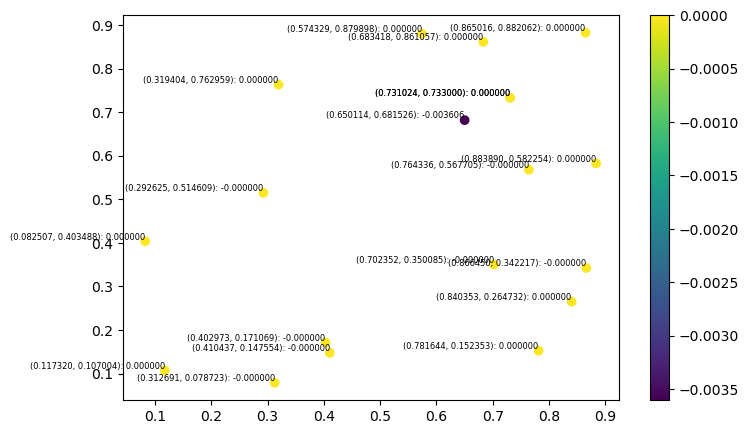

In [13]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)

# Scatter plot
scatter = ax.scatter(X_data[:, 0], X_data[:, 1], c=Y_data)

# Adding a color bar
plt.colorbar(scatter)

# Looping over the data points to add labels with 16 digits of precision
for i in range(len(X_data)):
    x_coord = f"{X_data[i, 0]:.6f}"
    y_coord = f"{X_data[i, 1]:.6f}"
    y_value = f"{Y_data[i]:.6f}"
    label = f"({x_coord}, {y_coord}): {y_value}"
    ax.text(X_data[i, 0], X_data[i, 1], label, fontsize=6, ha='right', va='bottom')

plt.show()

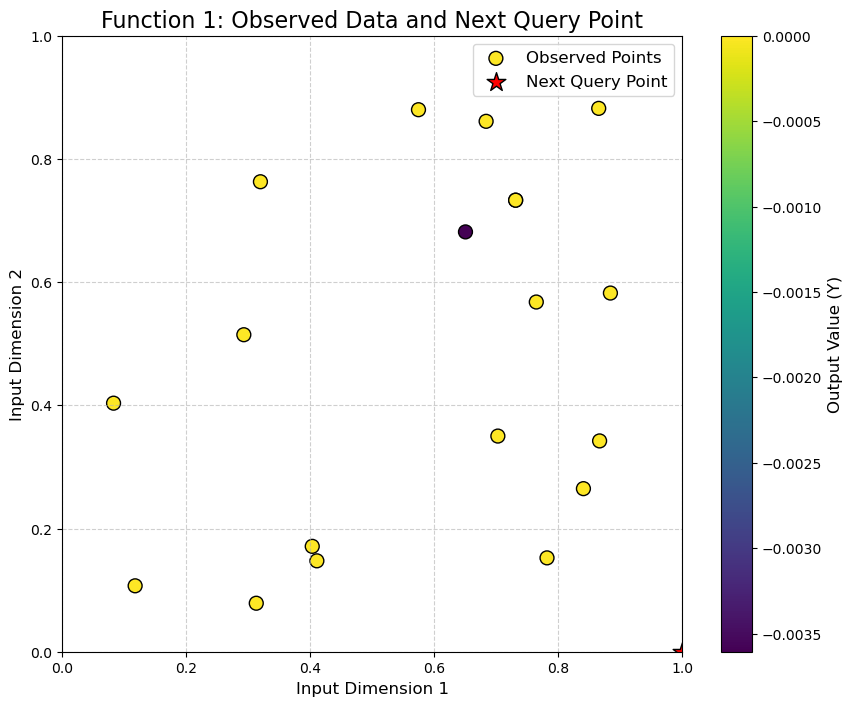

In [14]:

import matplotlib.pyplot as plt
X_next = best_x

# --- Create the Scatter Plot ---

plt.figure(figsize=(10, 8))

# 1. Plot the historical data points
# The color of each point is determined by its output value (Y_data)
scatter = plt.scatter(
    X_data[:, 0],
    X_data[:, 1],
    c=Y_data,
    cmap='viridis', # A nice color map
    s=100,          # Size of the points
    edgecolors='k', # Black edge color for better visibility
    label='Observed Points'
)

# 2. Highlight the next point to be queried
plt.scatter(
    X_next[0],
    X_next[1],
    c='red',
    s=200,          # Make it larger
    marker='*',     # Use a star marker
    edgecolors='k',
    label='Next Query Point'
)

# 3. Add labels and a color bar
plt.title('Function 1: Observed Data and Next Query Point', fontsize=16)
plt.xlabel('Input Dimension 1', fontsize=12)
plt.ylabel('Input Dimension 2', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Add a color bar to show what the colors represent
cbar = plt.colorbar(scatter)
cbar.set_label('Output Value (Y)', fontsize=12)

# Set plot limits to the bounds of your search space
plt.xlim(0, 1)
plt.ylim(0, 1)

# Save the plot to a file
plt.savefig('function1_visualization.png')

plt.show()
